## IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import sys
from pandarallel import pandarallel

In [3]:
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
src_path = os.path.join(project_root, 'src')

In [4]:
if src_path not in sys.path:
    sys.path.append(src_path)

In [5]:
from imputation import (
    imputar_por_regex,
    imputar_por_grupos,
    REGLAS_DRIVE,
    REGLAS_CONDITION,
    REGLAS_TYPE,
    REGLAS_CYLINDERS
)

In [6]:
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [7]:
pandarallel.initialize(progress_bar=True, verbose=0)

In [8]:
PATH_RAW = '../data/raw/vehicles.csv'
df = pd.read_csv(PATH_RAW)

In [9]:
print(f"Dimensiones iniciales: {df.shape}")
print(f"Columnas detectadas: {list(df.columns)}")

Dimensiones iniciales: (426880, 26)
Columnas detectadas: ['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']


In [10]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [12]:
null_percentage = df.isnull().mean() * 100
print(null_percentage)

id                0.000000
url               0.000000
region            0.000000
region_url        0.000000
price             0.000000
year              0.282281
manufacturer      4.133714
model             1.236179
condition        40.785232
cylinders        41.622470
fuel              0.705819
odometer          1.030735
title_status      1.930753
transmission      0.598763
VIN              37.725356
drive            30.586347
size             71.767476
type             21.752717
paint_color      30.501078
image_url         0.015930
description       0.016398
county          100.000000
state             0.000000
lat               1.534155
long              1.534155
posting_date      0.015930
dtype: float64


In [13]:
cols_to_drop = [
    'id', 'url', 'region_url', 'image_url', 'lat', 'long',
    'county', 'region', 'VIN'
]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         426880 non-null  int64  
 1   year          425675 non-null  float64
 2   manufacturer  409234 non-null  object 
 3   model         421603 non-null  object 
 4   condition     252776 non-null  object 
 5   cylinders     249202 non-null  object 
 6   fuel          423867 non-null  object 
 7   odometer      422480 non-null  float64
 8   title_status  418638 non-null  object 
 9   transmission  424324 non-null  object 
 10  drive         296313 non-null  object 
 11  size          120519 non-null  object 
 12  type          334022 non-null  object 
 13  paint_color   296677 non-null  object 
 14  description   426810 non-null  object 
 15  state         426880 non-null  object 
 16  posting_date  426812 non-null  object 
dtypes: float64(2), int64(1), object(14)
memory usage

In [15]:
# imprimir total de nulos por columna
null_counts = df.isnull().sum()
print(null_counts)

price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
drive           130567
size            306361
type             92858
paint_color     130203
description         70
state                0
posting_date        68
dtype: int64


In [16]:
# summary de valores numericos
df.describe()

,price,year,odometer
count,4.268800e+05,425675.000000,4.224800e+05
mean,7.519903e+04,2011.235191,9.804333e+04
std,1.218228e+07,9.452120,2.138815e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,5.900000e+03,2008.000000,3.770400e+04
50%,1.395000e+04,2013.000000,8.554800e+04
75%,2.648575e+04,2017.000000,1.335425e+05
max,3.736929e+09,2022.000000,1.000000e+07


In [17]:
# valores numericos mas repetidos de cada columna
for column in df.select_dtypes(include=[np.number]).columns:
    print(f"Column: {column}")
    print(df[column].value_counts().head())
    print("\n")

Column: price
price
0       32895
6995     3169
7995     3129
9995     2867
8995     2837
Name: count, dtype: int64


Column: year
year
2017.0    36420
2018.0    36369
2015.0    31538
2013.0    30794
2016.0    30434
Name: count, dtype: int64


Column: odometer
odometer
100000.0    2263
1.0         2246
0.0         1965
200000.0    1728
150000.0    1603
Name: count, dtype: int64




In [18]:
# A) PRECIO: Quitamos coches de 0$ (scams) y coches de >$100k (superdeportivos que rompen el modelo)
df = df[(df['price'] > 500) & (df['price'] < 100000)]

# B) AÑO: Nos centramos en el mercado moderno
df = df[(df['year'] > 1990) & (df['year'] <= 2024)]

# C) MILLAS: Quitamos coches con 0 millas (error) o >400k
df = df[(df['odometer'] > 1000) & (df['odometer'] < 400000)]

print(f"Dimensiones tras filtros de negocio: {df.shape}")

Dimensiones tras filtros de negocio: (359869, 17)


In [19]:
df = imputar_por_regex(df, 'drive', REGLAS_DRIVE)

--- Imputando 'drive' por Regex ---
Recuperados: 59894 registros.



In [20]:
df = imputar_por_regex(df, 'condition', REGLAS_CONDITION)

--- Imputando 'condition' por Regex ---
Recuperados: 74473 registros.



In [21]:
df = imputar_por_regex(df, 'type', REGLAS_TYPE)

--- Imputando 'type' por Regex ---
Recuperados: 46807 registros.



In [12]:
df = imputar_por_regex(df, 'cylinders', REGLAS_CYLINDERS)

Recuperados: 123739 registros.



In [23]:
df = imputar_por_grupos(df)

--- Imputando por Estadística de Grupo (Modelo/Fabricante) ---
Mapeando fabricantes...
Columna 'fuel': 1942 recuperados.
Columna 'transmission': 1426 recuperados.
Columna 'type': 26143 recuperados.
Columna 'drive': 46091 recuperados.
Columna 'cylinders': 40791 recuperados.
Imputando Años y Millas...


In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isna().sum() > 0:
        nulos_restantes = df[col].isna().sum()
        print(f"Rellenando {nulos_restantes} nulos finales en '{col}' con 'Unknown'")
        df[col].fillna('Unknown', inplace=True)

Rellenando 10248 nulos finales en 'manufacturer' con 'Unknown'
Rellenando 3130 nulos finales en 'model' con 'Unknown'
Rellenando 927 nulos finales en 'cylinders' con 'Unknown'
Rellenando 116 nulos finales en 'fuel' con 'Unknown'
Rellenando 6037 nulos finales en 'title_status' con 'Unknown'
Rellenando 10 nulos finales en 'transmission' con 'Unknown'
Rellenando 1367 nulos finales en 'drive' con 'Unknown'
Rellenando 259186 nulos finales en 'size' con 'Unknown'
Rellenando 621 nulos finales en 'type' con 'Unknown'
Rellenando 101771 nulos finales en 'paint_color' con 'Unknown'
Rellenando 2 nulos finales en 'description' con 'Unknown'


In [25]:
cols_to_drop_final = [
    'VIN',           # Es un ID único, no predice precio
    'id',            # ID interno
    'description',   # Ya extrajimos lo útil, ahora solo ocupa espacio
    'size',          # Faltan 300k datos, no aporta valor
    'posting_date',  # No vamos a hacer series temporales
    'url', 'image_url', 'region_url', 'lat', 'long','county' 
]

In [26]:
existing_cols_to_drop = [c for c in cols_to_drop_final if c in df.columns]
df.drop(columns=existing_cols_to_drop, inplace=True)
print(f"Columnas eliminadas: {existing_cols_to_drop}")

Columnas eliminadas: ['description', 'size', 'posting_date']


In [27]:
if df['year'].isna().sum() > 0:
    df['year'].fillna(df['year'].median(), inplace=True)
if df['odometer'].isna().sum() > 0:
    df['odometer'].fillna(df['odometer'].median(), inplace=True)

In [28]:
def text_to_num(text):
    if pd.isna(text) or text == 'Unknown':
        return np.nan
    # Extraer el primer número que encuentre
    match = re.search(r'(\d+)', str(text))
    return int(match.group(1)) if match else np.nan

print("Transformando cilindros a numérico...")
df['cylinders_num'] = df['cylinders'].apply(text_to_num)

Transformando cilindros a numérico...


In [29]:
mediana_cyl = df['cylinders_num'].median()
df['cylinders_num'].fillna(mediana_cyl, inplace=True)

In [30]:
if 'cylinders' in df.columns:
    df.drop(columns=['cylinders'], inplace=True)

In [31]:
if 'description' in df.columns:
    df.drop(columns=['description'], inplace=True)
    print("Columna 'description' eliminada para liberar memoria.")

In [32]:
print(f"Dimensiones finales: {df.shape}")
print(f"Total Nulos: {df.isna().sum().sum()}")

Dimensiones finales: (359869, 14)
Total Nulos: 0


In [34]:
# 6. FILTRADO FINAL: LOS 3 MODELOS DE ESTUDIO
# ==============================================================================
print("\n--- INICIANDO FILTRADO EXCLUSIVO (F-150, SILVERADO, CAMRY) ---")

# Guardamos dimensiones antes del corte
rows_start = df.shape[0]

# 1. Normalizamos texto para facilitar las búsquedas
# (Creamos columnas temporales en minúsculas para no fallar por mayúsculas/minúsculas)
df['manuf_temp'] = df['manufacturer'].astype(str).str.lower()
df['model_temp'] = df['model'].astype(str).str.lower()

# Inicializamos la columna unificada
df['model_unified'] = np.nan


--- INICIANDO FILTRADO EXCLUSIVO (F-150, SILVERADO, CAMRY) ---


In [35]:
# -------------------------------------------------------------------------
# A. FORD F-150
# -------------------------------------------------------------------------
# Lógica: Fabricante Ford + Modelo que contenga f150.
# Excluimos f-250/350 explícitamente.
mask_ford = (
    (df['manuf_temp'] == 'ford') &
    (df['model_temp'].str.contains(r'f-?150', regex=True)) &
    (~df['model_temp'].str.contains(r'250|350|450', regex=True))
)
df.loc[mask_ford, 'model_unified'] = 'Ford F-150'
df.loc[mask_ford, 'manufacturer'] = 'Ford' # Corregimos el nombre por si acaso

In [36]:
# -------------------------------------------------------------------------
# B. CHEVROLET SILVERADO 1500
# -------------------------------------------------------------------------
# Lógica: Fabricante Chevy + Modelo Silverado O 1500.
# Excluimos 2500/3500 (Heavy Duty).
mask_chevy = (
    (df['manuf_temp'].str.contains(r'chev', regex=True)) &
    (df['model_temp'].str.contains(r'silverado|1500', regex=True)) &
    (~df['model_temp'].str.contains(r'2500|3500', regex=True))
)
df.loc[mask_chevy, 'model_unified'] = 'Chevrolet Silverado 1500'
df.loc[mask_chevy, 'manufacturer'] = 'Chevrolet'

In [37]:
# -------------------------------------------------------------------------
# C. TOYOTA CAMRY
# -------------------------------------------------------------------------
# Lógica: Fabricante Toyota + Modelo Camry.
mask_camry = (
    (df['manuf_temp'] == 'toyota') &
    (df['model_temp'].str.contains(r'camry', regex=True))
)
df.loc[mask_camry, 'model_unified'] = 'Toyota Camry'
df.loc[mask_camry, 'manufacturer'] = 'Toyota'

In [38]:
# -------------------------------------------------------------------------
# 2. APLICAR EL CORTE
# -------------------------------------------------------------------------
# Nos quedamos SOLO con las filas que tienen uno de los 3 modelos
df_filtered = df.dropna(subset=['model_unified']).copy()

# Reemplazamos la columna 'model' sucia con la unificada limpia
df_filtered['model'] = df_filtered['model_unified']

# Borramos columnas temporales
df_filtered.drop(columns=['manuf_temp', 'model_temp', 'model_unified'], inplace=True)

In [39]:
# -------------------------------------------------------------------------
# 3. LIMPIEZA LEGAL FINAL (Clean Title + No Salvage)
# -------------------------------------------------------------------------
# Re-aplicamos esto para asegurarnos al 100% de que la comparativa es justa
if 'title_status' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['title_status'] == 'clean']
if 'condition' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['condition'] != 'salvage']

In [41]:
# 4. RESULTADOS
# -------------------------------------------------------------------------
rows_end = df_filtered.shape[0]

print(f"Filas iniciales (Todo el mercado): {rows_start}")
print(f"Filas finales (Solo 3 Modelos):    {rows_end}")
print("-" * 30)
print("Conteo final por modelo:")
print(df_filtered['model'].value_counts())

# Sobrescribimos df para que el código de guardado funcione
df = df_filtered

Filas iniciales (Todo el mercado): 359869
Filas finales (Solo 3 Modelos):    28370
------------------------------
Conteo final por modelo:
model
Ford F-150                  13252
Chevrolet Silverado 1500    10899
Toyota Camry                 4219
Name: count, dtype: int64


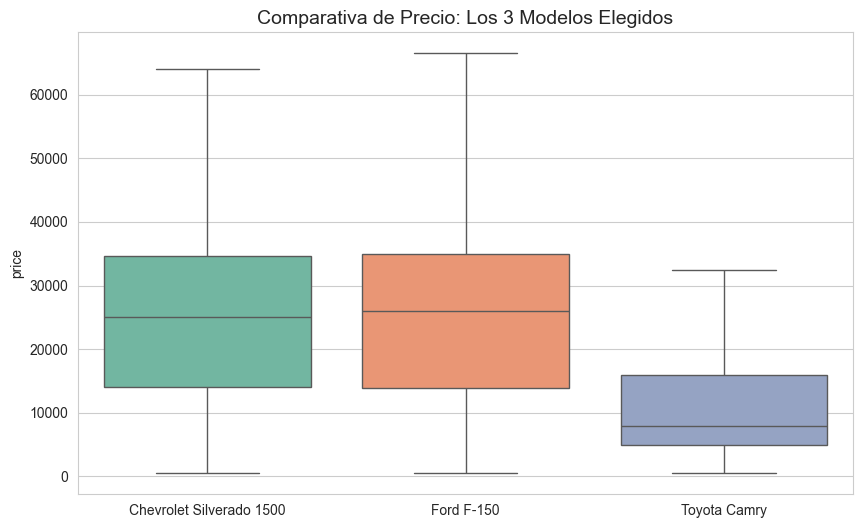

In [42]:
# Pequeña visualización para confirmar
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='model', y='price', palette='Set2', showfliers=False)
plt.title('Comparativa de Precio: Los 3 Modelos Elegidos', fontsize=14)
plt.xlabel('')
plt.show()

In [43]:
PATH_PROCESSED = '../data/processed/df_cleaned.csv'

df.to_csv(PATH_PROCESSED, index=False)

In [44]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

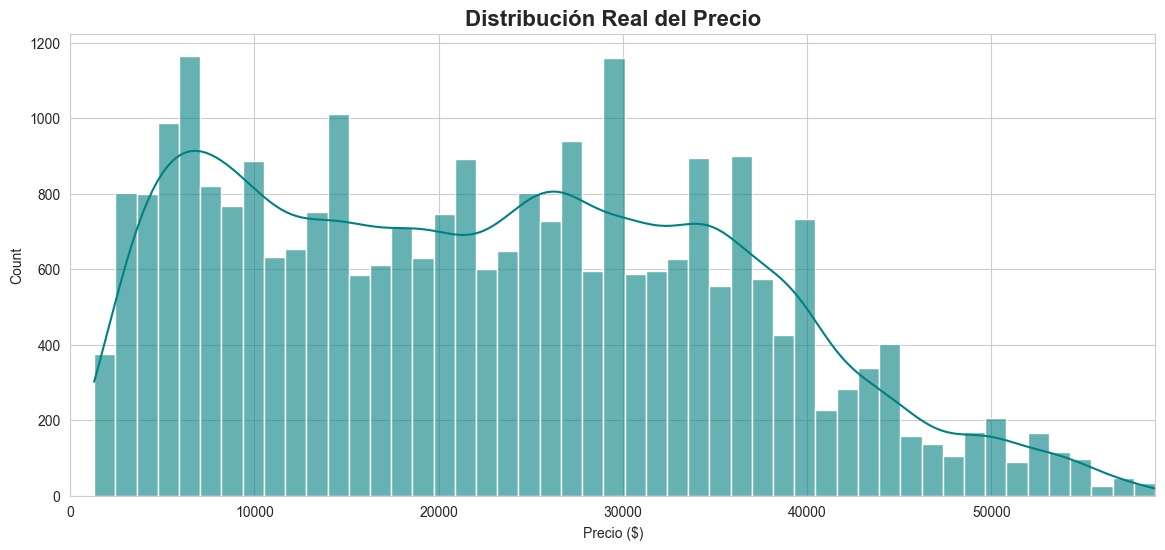

In [45]:
plt.figure(figsize=(14, 6))

# Filtramos visualmente solo para el gráfico (del 1% al 99% de los datos)
# Esto quita los coches de $1M que "chafan" el gráfico
q_low = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
df_filtered = df[(df['price'] > q_low) & (df['price'] < q_high)]

sns.histplot(df_filtered['price'], bins=50, kde=True, color='teal', alpha=0.6)
plt.title('Distribución Real del Precio', fontsize=16, fontweight='bold')
plt.xlabel('Precio ($)')
plt.xlim(0, q_high) # Forzamos el límite del eje X
plt.show()

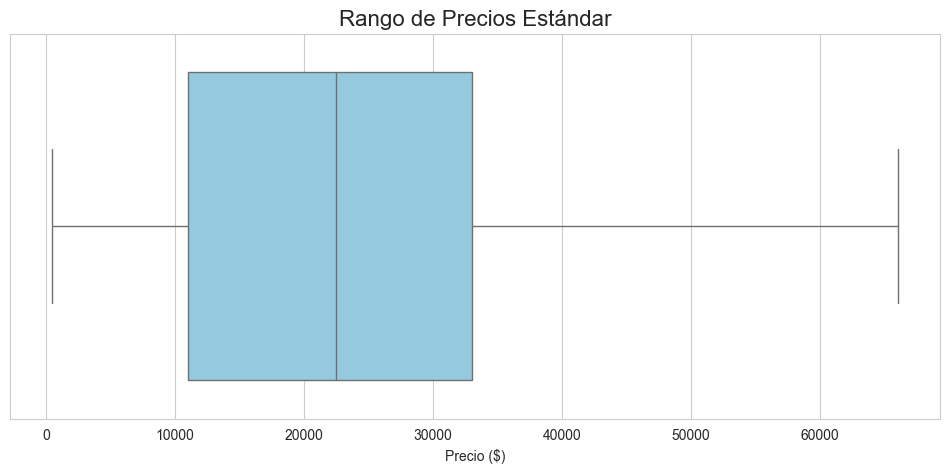

In [46]:
plt.figure(figsize=(12, 5))

sns.boxplot(x=df['price'], color='skyblue', showfliers=False)

plt.title('Rango de Precios Estándar', fontsize=16)
plt.xlabel('Precio ($)')
plt.show()

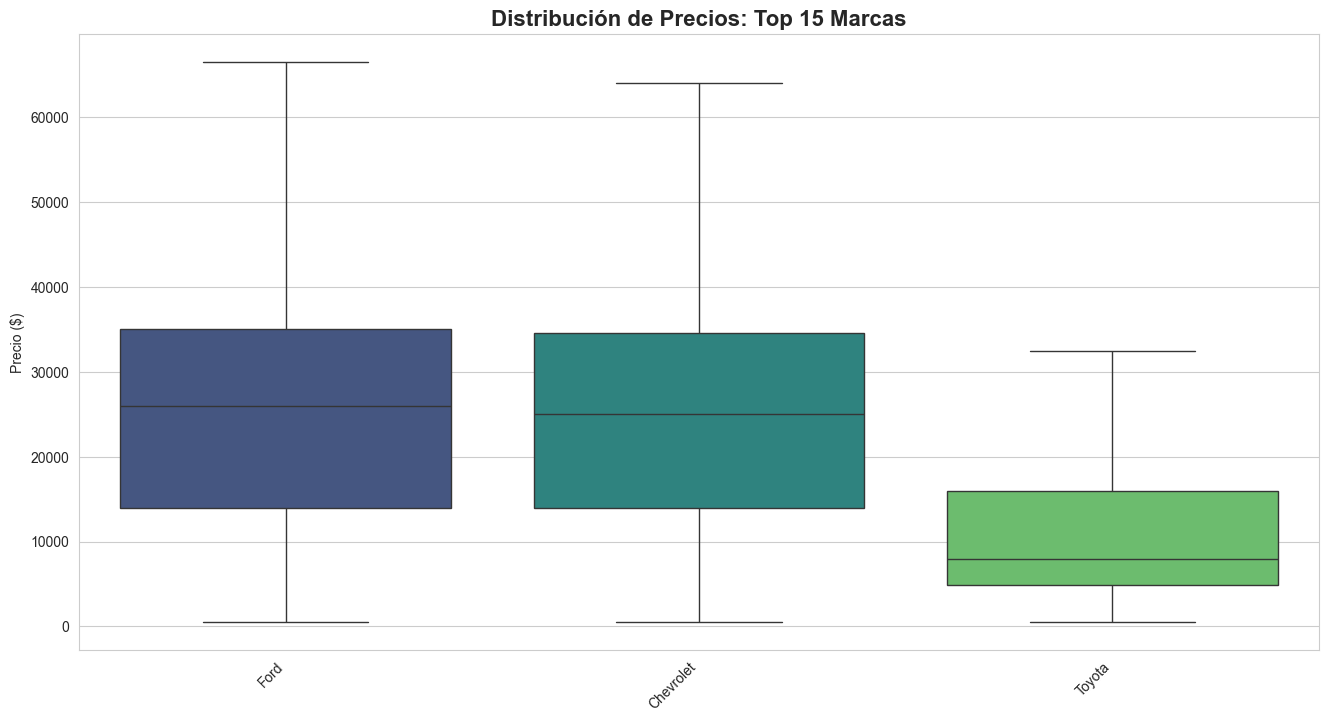

In [47]:
top_brands = df['manufacturer'].value_counts().head(15).index

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df[df['manufacturer'].isin(top_brands)],
    x='manufacturer',
    y='price',
    order=top_brands, # Mantenemos el orden de popularidad
    showfliers=False, 
    palette='viridis'
)
plt.title('Distribución de Precios: Top 15 Marcas', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotamos nombres para que se lean
plt.xlabel('')
plt.ylabel('Precio ($)')
plt.show()

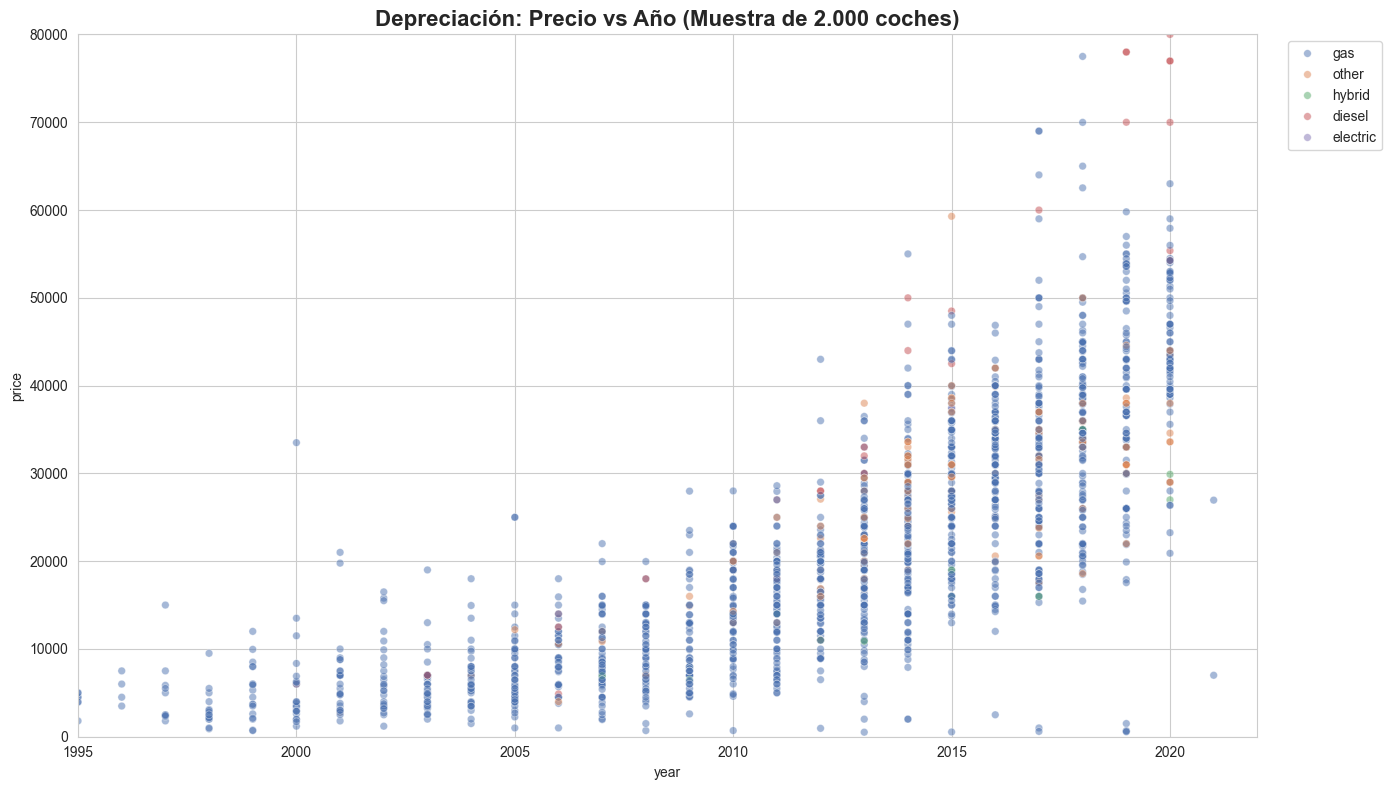

In [48]:
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df.sample(2000, random_state=42),
    x='year',
    y='price',
    hue='fuel',      # Color por combustible
    alpha=0.5,       # Transparencia para ver solapamientos
    s=30,            # Tamaño de punto pequeño
    palette='deep'
)
plt.title('Depreciación: Precio vs Año (Muestra de 2.000 coches)', fontsize=16, fontweight='bold')
plt.ylim(0, 80000) # Centramos la vista en el rango normal
plt.xlim(1995, 2022)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') # Leyenda fuera
plt.tight_layout()
plt.show()

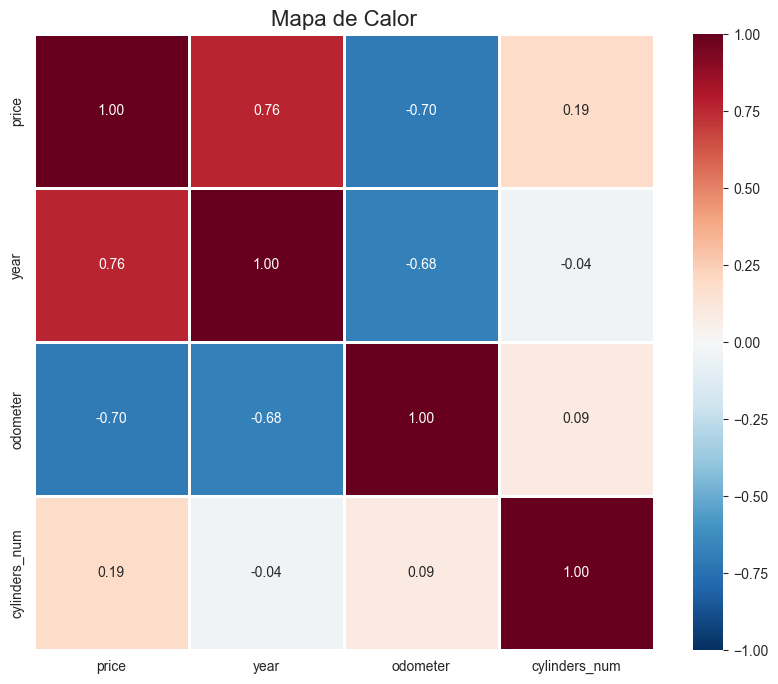

In [49]:
plt.figure(figsize=(10, 8))

# Seleccionamos columnas numéricas
cols_corr = ['price', 'year', 'odometer', 'cylinders_num']
# Calculamos correlación
corr = df[cols_corr].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=1
)
plt.title('Mapa de Calor', fontsize=16)
plt.show()